# Employee Attrition Prediction
### Predict whether an employee will leave the company

## Section 1 — Import Libraries & Load Data

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve)
from sklearn.preprocessing import LabelEncoder
import joblib

In [19]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f' Dataset loaded: {df.shape[0]} employees, {df.shape[1]} columns')
df.head()

 Dataset loaded: 1470 employees, 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


##  Section 2 — Exploratory Data Analysis (EDA)

In [20]:
# Basic info
print(' Column Data Types:')
print(df.dtypes.value_counts())
print()
print(' Missing Values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '  No missing values!')

 Column Data Types:
int64     26
object     9
Name: count, dtype: int64

 Missing Values:
  No missing values!


 Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

→ Attrition rate: 16.1%
→ This means 1 in 6 employees leaves the company


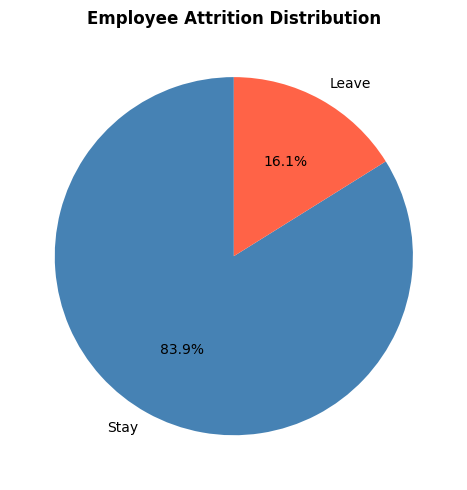

In [21]:
# Target distribution
print(' Attrition Distribution:')
print(df['Attrition'].value_counts())
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100
print(f'\n→ Attrition rate: {attrition_rate:.1f}%')
print('→ This means 1 in 6 employees leaves the company')

# Pie chart
fig, ax = plt.subplots(figsize=(5, 5))
df['Attrition'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['steelblue', 'tomato'],
    labels=['Stay', 'Leave'], startangle=90, ax=ax
)
ax.set_title('Employee Attrition Distribution', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

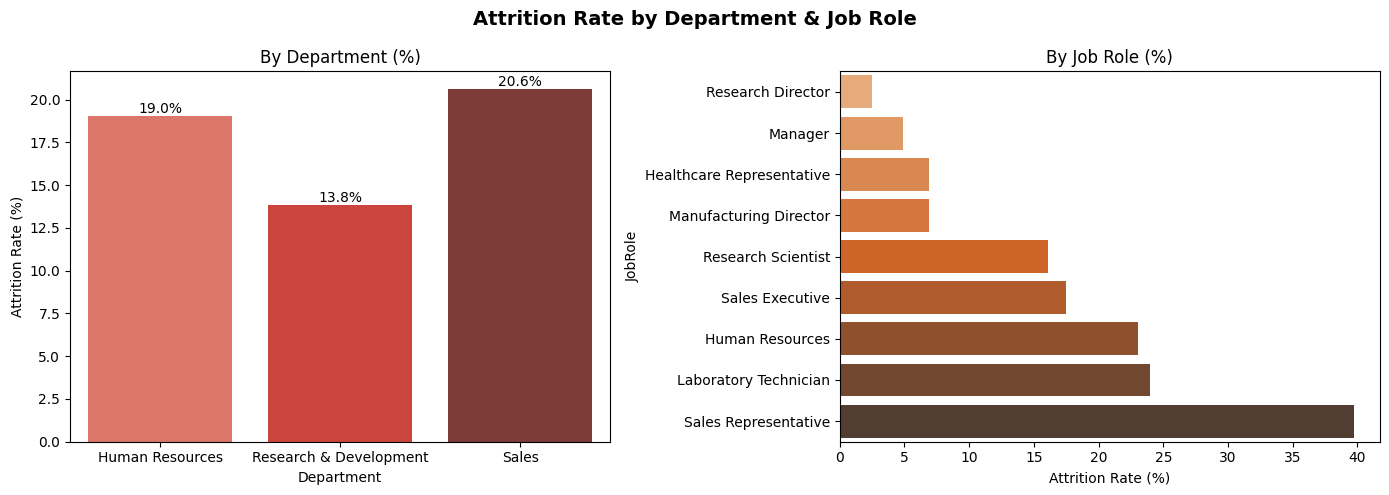

In [22]:
# Attrition by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attrition Rate by Department & Job Role', fontsize=14, fontweight='bold')

dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index(name='AttritionRate')
sns.barplot(data=dept_attrition, x='Department', y='AttritionRate', palette='Reds_d', ax=axes[0])
axes[0].set_title('By Department (%)')
axes[0].set_ylabel('Attrition Rate (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

role_attrition = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index(name='AttritionRate').sort_values('AttritionRate')
sns.barplot(data=role_attrition, y='JobRole', x='AttritionRate', palette='Oranges_d', ax=axes[1])
axes[1].set_title('By Job Role (%)')
axes[1].set_xlabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()

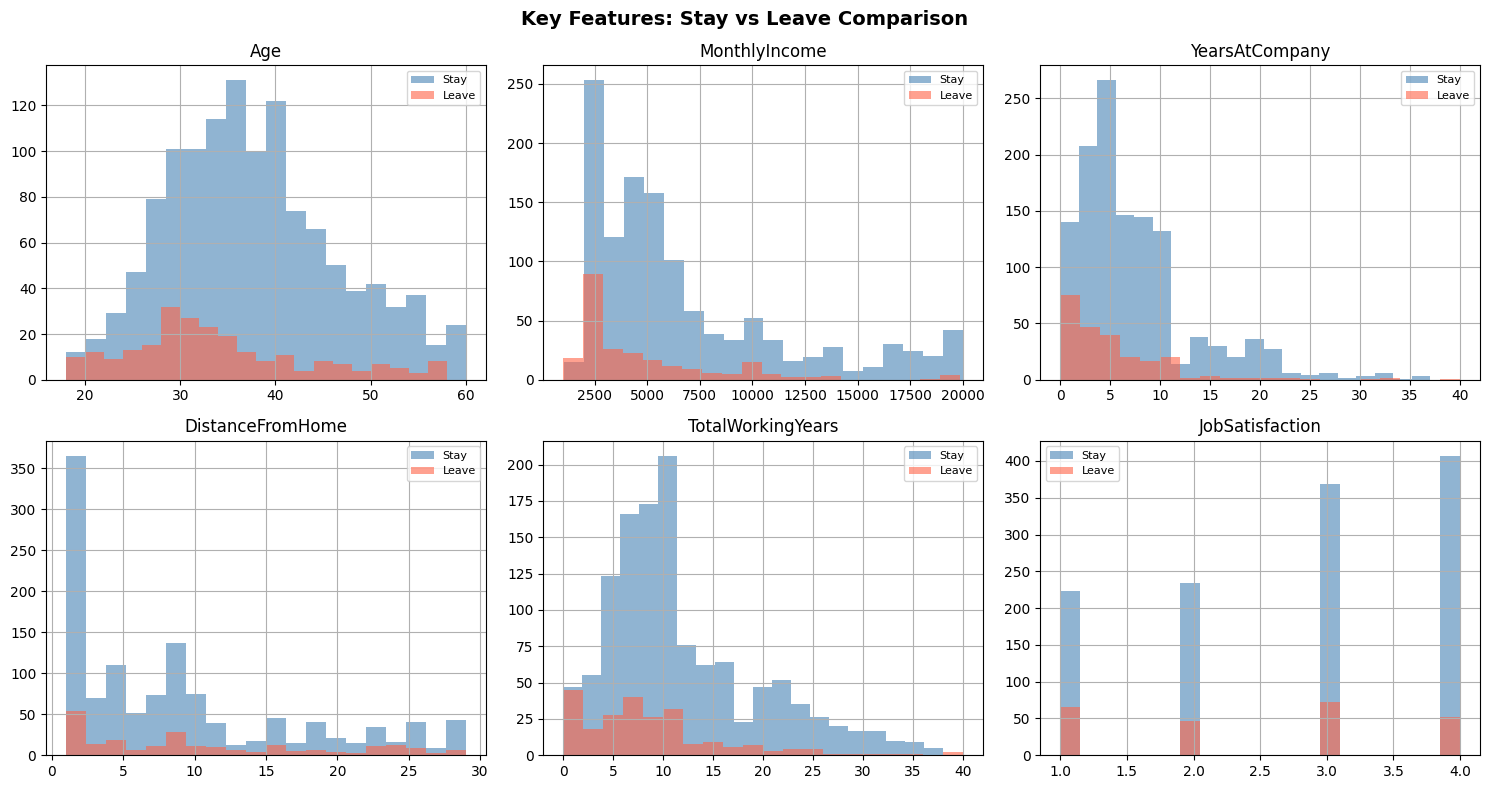

In [56]:
# Numeric feature distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Key Features: Stay vs Leave Comparison', fontsize=14, fontweight='bold')

numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany',
                'DistanceFromHome', 'TotalWorkingYears', 'JobSatisfaction']

for i, col in enumerate(numeric_cols):
    ax = axes[i // 3][i % 3]
    df[df['Attrition'] == 'No'][col].hist(bins=20, alpha=0.6, label='Stay', color='steelblue', ax=ax)
    df[df['Attrition'] == 'Yes'][col].hist(bins=20, alpha=0.6, label='Leave', color='tomato', ax=ax)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

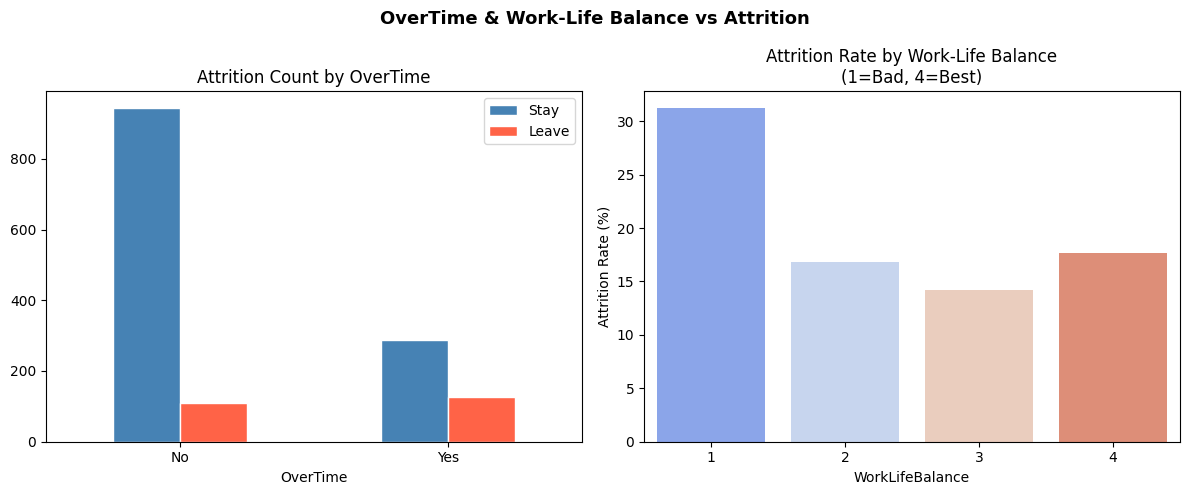

In [57]:
# Overtime impact
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('OverTime & Work-Life Balance vs Attrition', fontsize=13, fontweight='bold')

ot_counts = df.groupby(['OverTime', 'Attrition']).size().unstack()
ot_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Attrition Count by OverTime')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Stay', 'Leave'])

wlb = df.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index(name='AttritionRate')
sns.barplot(data=wlb, x='WorkLifeBalance', y='AttritionRate', palette='coolwarm', ax=axes[1])
axes[1].set_title('Attrition Rate by Work-Life Balance\n(1=Bad, 4=Best)')
axes[1].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()

## 🧹 Section 3 — Data Cleaning & Feature Engineering

In [58]:
df_model = df.copy()

# Drop constant/useless columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns], inplace=True)
print(f' Dropped useless columns: {cols_to_drop}')

# Encode target
df_model['Attrition'] = (df_model['Attrition'] == 'Yes').astype(int)
print(' Target encoded: Yes=1 (Leave), No=0 (Stay)')

 Dropped useless columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
 Target encoded: Yes=1 (Leave), No=0 (Stay)


In [59]:
# Feature Engineering — create 5 new meaningful columns
df_model['IncomePerYear']     = df_model['MonthlyIncome'] / (df_model['YearsAtCompany'] + 1)
df_model['SatisfactionScore'] = (df_model['JobSatisfaction'] +
                                   df_model['EnvironmentSatisfaction'] +
                                   df_model['RelationshipSatisfaction']) / 3
df_model['CareerGrowthRate']  = df_model['YearsAtCompany'] / (df_model['TotalWorkingYears'] + 1)
df_model['PromotionLag']      = df_model['YearsAtCompany'] - df_model['YearsSinceLastPromotion']
df_model['OverTimeBinary']    = (df_model['OverTime'] == 'Yes').astype(int)

print(' New features created:')
print('   • IncomePerYear      — salary fairness relative to tenure')
print('   • SatisfactionScore  — average of 3 satisfaction scores')
print('   • CareerGrowthRate   — how fast they are growing')
print('   • PromotionLag       — years without a promotion')
print('   • OverTimeBinary     — 1=works overtime, 0=does not')

 New features created:
   • IncomePerYear      — salary fairness relative to tenure
   • SatisfactionScore  — average of 3 satisfaction scores
   • CareerGrowthRate   — how fast they are growing
   • PromotionLag       — years without a promotion
   • OverTimeBinary     — 1=works overtime, 0=does not


In [60]:
# Encode all remaining text columns
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c != 'OverTime']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

if 'OverTime' in df_model.columns:
    df_model.drop(columns=['OverTime'], inplace=True)

print(f' Encoding complete. Final shape: {df_model.shape}')
df_model.head(3)

 Encoding complete. Final shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomePerYear,SatisfactionScore,CareerGrowthRate,PromotionLag,OverTimeBinary
0,41,1,2,1102,2,1,2,1,2,0,...,1,6,4,0,5,856.142857,2.333333,0.666667,6,1
1,49,0,1,279,1,8,1,1,3,1,...,3,10,7,1,7,466.363636,3.000000,0.909091,9,0
2,37,1,2,1373,1,2,2,4,4,1,...,3,0,0,0,0,2090.000000,3.000000,0.000000,0,1


##  Section 4 — Model Building

In [61]:
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f' Training set : {X_train.shape[0]} employees')
print(f' Testing set  : {X_test.shape[0]} employees')
print(f'   Features used: {X.shape[1]} columns')

 Training set : 1176 employees
 Testing set  : 294 employees
   Features used: 34 columns


In [73]:
# Compare 3 models
print(' Comparing 3 models using 5-fold Cross Validation...\n')

models_compare = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
compare_results = {}
for name, model in models_compare.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    compare_results[name] = scores.mean()
    print(f'  {name:<25}  AUC = {scores.mean():.4f} ± {scores.std():.4f}')

best_name = max(compare_results, key=compare_results.get)
print(f'\n Best model: {best_name}')

 Comparing 3 models using 5-fold Cross Validation...

  Logistic Regression        AUC = 0.7333 ± 0.0345
  Random Forest              AUC = 0.7880 ± 0.0214
  Gradient Boosting          AUC = 0.8055 ± 0.0260

 Best model: Gradient Boosting


##  Section 5 — Model Evaluation

In [64]:
y_pred       = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_proba)

print('FINAL MODEL METRICS')
print(f'  Accuracy   : {accuracy:.4f} ({accuracy*100:.1f}%)')
print(f'  Precision  : {precision:.4f}')
print(f'  Recall     : {recall:.4f}')
print(f'  F1 Score   : {f1:.4f}')
print(f'  AUC-ROC    : {auc:.4f}')

FINAL MODEL METRICS
  Accuracy   : 0.8333 (83.3%)
  Precision  : 0.4375
  Recall     : 0.1489
  F1 Score   : 0.2222
  AUC-ROC    : 0.7868


In [65]:
print(' Full Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Stay', 'Leave']))

 Full Classification Report:
              precision    recall  f1-score   support

        Stay       0.86      0.96      0.91       247
       Leave       0.44      0.15      0.22        47

    accuracy                           0.83       294
   macro avg       0.65      0.56      0.56       294
weighted avg       0.79      0.83      0.80       294



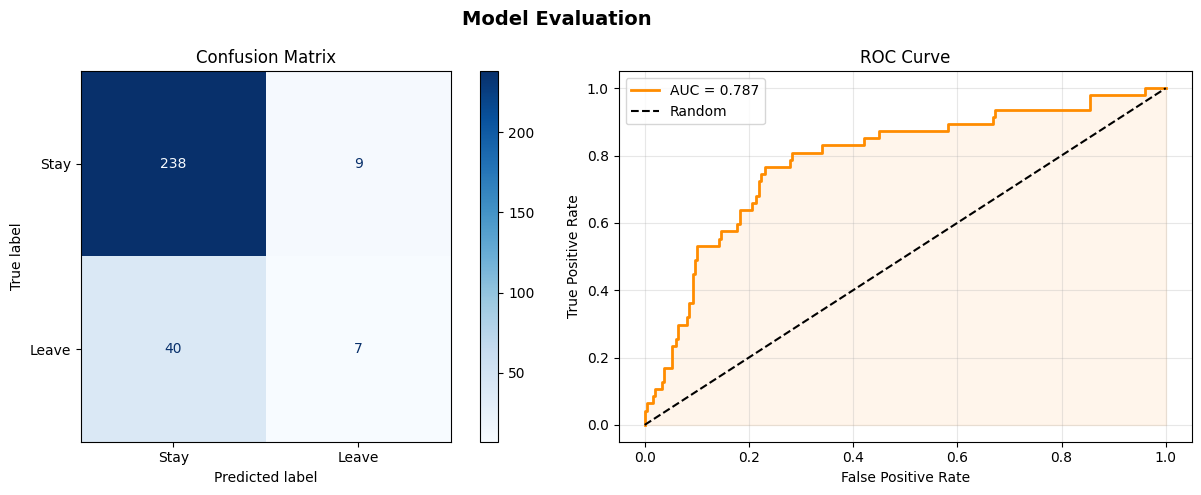

In [66]:
++# Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Leave'])
disp.plot(cmap='Blues', values_format='d', ax=axes[0])
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', linewidth=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='darkorange')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6 — Feature Importance & Business Insights

In [67]:
feature_importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(' Top 15 Features Driving Attrition:')
print(feature_importance.head(15).to_string(index=False))

 Top 15 Features Driving Attrition:
             Feature  Importance
       MonthlyIncome    0.068837
                 Age    0.062397
      OverTimeBinary    0.048471
   TotalWorkingYears    0.048097
           DailyRate    0.044432
         MonthlyRate    0.042627
       IncomePerYear    0.039651
    CareerGrowthRate    0.039147
        PromotionLag    0.038404
          HourlyRate    0.037949
   SatisfactionScore    0.037310
    DistanceFromHome    0.036424
      YearsAtCompany    0.036399
YearsWithCurrManager    0.035301
  NumCompaniesWorked    0.032214


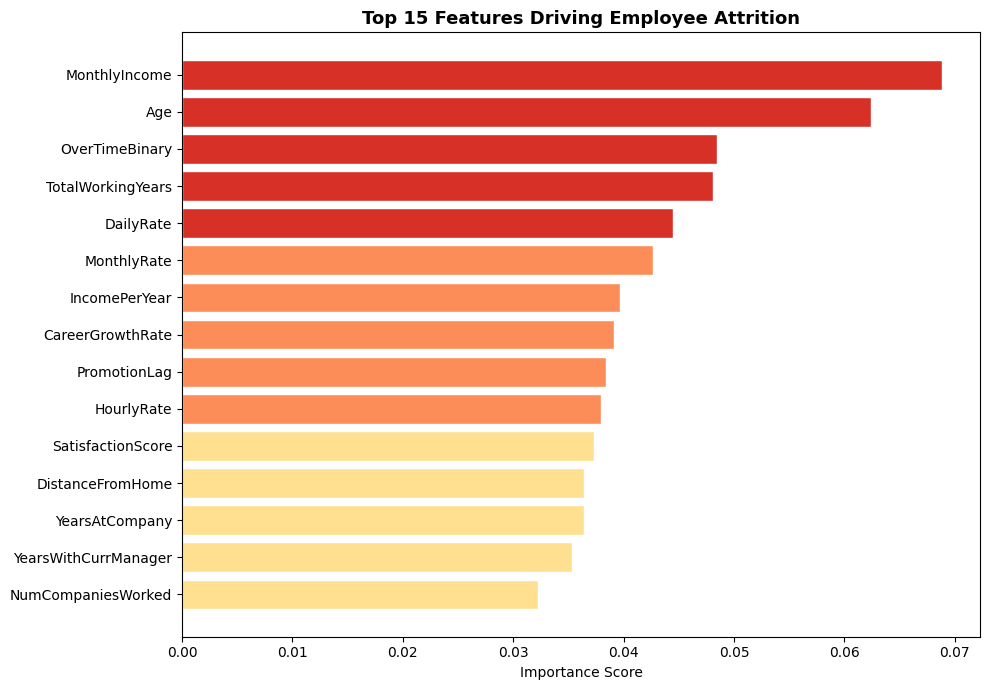

In [68]:
top15 = feature_importance.head(15)
colors = ['#d73027' if i < 5 else '#fc8d59' if i < 10 else '#fee090' for i in range(len(top15))]

plt.figure(figsize=(10, 7))
plt.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors[::-1], edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Top 15 Features Driving Employee Attrition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [70]:
print('\n╔══════════════════════════════════════════════╗')
print('║           BUSINESS INSIGHTS                  ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Top driver : {feature_importance.iloc[0]["Feature"]:<30} ║')
print(f'║  Model catches {recall*100:.1f}% of employees who leave  ║')
print(f'║  AUC Score  : {auc:.3f}                          ║')
print('╠══════════════════════════════════════════════╣')
print('║  HR Recommendations:                         ║')
print('║  1. Reduce overtime for high-risk employees  ║')
print('║  2. Review salaries of long-tenure staff     ║')
print('║  3. Promote employees with long promo gaps   ║')
print('║  4. Improve job satisfaction programs        ║')
print('╚══════════════════════════════════════════════╝')


╔══════════════════════════════════════════════╗
║           BUSINESS INSIGHTS                  ║
╠══════════════════════════════════════════════╣
║  Top driver : MonthlyIncome                  ║
║  Model catches 14.9% of employees who leave  ║
║  AUC Score  : 0.787                          ║
╠══════════════════════════════════════════════╣
║  HR Recommendations:                         ║
║  1. Reduce overtime for high-risk employees  ║
║  2. Review salaries of long-tenure staff     ║
║  3. Promote employees with long promo gaps   ║
║  4. Improve job satisfaction programs        ║
╚══════════════════════════════════════════════╝


## Section 7 — Predict for a New Employee

In [71]:
def predict_attrition(employee_data: dict) -> dict:
    input_df = pd.DataFrame([employee_data])
    if 'IncomePerYear' not in input_df.columns and 'MonthlyIncome' in input_df.columns:
        input_df['IncomePerYear'] = input_df['MonthlyIncome'] / (input_df.get('YearsAtCompany', 1) + 1)
    if 'SatisfactionScore' not in input_df.columns:
        sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']
        if all(c in input_df.columns for c in sat_cols):
            input_df['SatisfactionScore'] = input_df[sat_cols].mean(axis=1)
    for col in X.columns:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[X.columns]
    proba = best_model.predict_proba(input_df)[0, 1]
    prediction = 'Leave ' if proba >= 0.5 else 'Stay '
    return {'prediction': prediction, 'probability_of_leaving': f'{proba:.2%}'}

# Test with a real employee from test set
example = {col: X_test.iloc[0][col] for col in X.columns}
result = predict_attrition(example)
actual = 'Leave ' if y_test.iloc[0] == 1 else 'Stay '

print(f'Actual Result  : {actual}')
print(f'Model Predicted: {result["prediction"]}')
print(f'Leave Probability: {result["probability_of_leaving"]}')

Actual Result  : Stay 
Model Predicted: Leave 
Leave Probability: 58.19%


## Section 8 — Save the Trained Model

In [72]:
joblib.dump({
    'model':           best_model,
    'encoders':        label_encoders,
    'feature_columns': list(X.columns),
    'metrics': {'accuracy': accuracy, 'precision': precision,
                'recall': recall, 'f1': f1, 'auc': auc}
}, 'attrition_model.pkl')

print(' Model saved as: attrition_model.pkl')
print('\n PROJECT COMPLETE!')
print(f'   Accuracy : {accuracy*100:.1f}%')
print(f'   AUC-ROC  : {auc:.4f}')
print(f'   Recall   : {recall*100:.1f}% of leavers correctly identified')

 Model saved as: attrition_model.pkl

 PROJECT COMPLETE!
   Accuracy : 83.3%
   AUC-ROC  : 0.7868
   Recall   : 14.9% of leavers correctly identified
